## 1. Import Libraries

In [1]:
#!/usr/bin/env python3
# ============================================
# 04_validate_clusters.py
# Validate clustering results using silhouette and CH scores
# Uses optimal k from find_optimal_k.py
# Saves cluster labels for later visualization
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import (
    D_GOWER_PATH,
    DISCLOSURE_THRESHOLD,
    OUTPUT_DIR,
    OPTIMAL_K_SUMMARY_PATH,
    RAW_PATH,
    SCALED_PATH,
    VALIDATION_RESULTS_PATH,
    X_PCA_PATH,
    PLOTS_DIR,
    labels_path,
)
from clustering_helpers import (
    load_data,
    evaluate_clustering,
)

## 2. Setup and Load Data

In [2]:
# -----------------------------
# Setup
# -----------------------------
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Create plots directory
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Loading datasets...")
X_raw, X_scaled,patient_ids = load_data(RAW_PATH, SCALED_PATH)


Loading datasets...


## 3. Load Optimal K Values

In [3]:
# -----------------------------
# Load optimal K values
# -----------------------------
opt_k_df = pd.read_csv(OPTIMAL_K_SUMMARY_PATH)
print(f"Loaded optimal k values from {OPTIMAL_K_SUMMARY_PATH}")

Loaded optimal k values from /Users/cj9491/Documents/UOB/REDUCE/git/reducehf/output/clustering/optimal_k_summary.csv


## 4. Load Distances and PCA

In [4]:
# -----------------------------
# Load distances and PCA
# -----------------------------
print("Loading Gower distance matrix...")
D_gower_path = D_GOWER_PATH
D_gower = pd.read_csv(D_gower_path, compression="gzip").values
print(f"Loaded D_gower from {D_gower_path}")

print("Loading PCA transformation...")
X_pca = pd.read_csv(X_PCA_PATH, compression="gzip").values
print(f"Loaded X_pca from {X_PCA_PATH}")


Loading Gower distance matrix...
Loaded D_gower from /Users/cj9491/Documents/UOB/REDUCE/git/reducehf/output/clustering/D_gower.csv.gz
Loading PCA transformation...
Loaded X_pca from /Users/cj9491/Documents/UOB/REDUCE/git/reducehf/output/clustering/X_pca.csv.gz


## 5. Evaluate All Configs

In [5]:
# -----------------------------
# Run all clustering configurations
# -----------------------------


results = []

configs = [
    ("raw_kmedoids_gower", D_gower),
    ("raw_agglomerative_gower", D_gower),
    ("raw_optics", D_gower),
    ("pca_kmeans_euclidean", X_pca),
    ("pca_agglomerative_euclidean", X_pca),
    ("pca_optics", X_pca),
]

print("\nRunning cluster validation...\n")

for cfg, data in configs:
    labels_file = labels_path(cfg)
    labels_df = pd.read_csv(labels_file, compression="gzip")
    labels = labels_df["cluster"].values
    print(f"Loaded labels for {cfg}")
    
     # Relabel small clusters (<=DISCLOSURE_THRESHOLD = 7) as -1
    counts = pd.Series(labels).value_counts()
    small_clusters = counts[counts <= DISCLOSURE_THRESHOLD].index
    labels[np.isin(labels, small_clusters)] = -1

    
    # Evaluate clustering quality (excluding -1 noise clusters)
    labels_eval = labels[labels != -1]
    if "raw" in cfg:
        X_eval = data[labels != -1][:, labels != -1]
        metric = "precomputed"
    else:
        X_eval = data[labels != -1]
        metric = "euclidean"

    res = evaluate_clustering(cfg, X_eval, labels_eval, metric=metric)
    results.append(res)

     # Save cluster labels 
    labels_df = pd.DataFrame({"patient_id": patient_ids, "cluster": labels})
    labels_df.to_csv(labels_file, index=False, compression="gzip")
    print(f"Saved labels to {labels_file}")
    
 



Running cluster validation...

Loaded labels for raw_kmedoids_gower
raw_kmedoids_gower: silhouette=0.336, calinski_harabasz=304.4
Saved labels to /Users/cj9491/Documents/UOB/REDUCE/git/reducehf/output/clustering/labels_raw_kmedoids_gower.csv.gz
Loaded labels for raw_agglomerative_gower
Saved labels to /Users/cj9491/Documents/UOB/REDUCE/git/reducehf/output/clustering/labels_raw_agglomerative_gower.csv.gz
Loaded labels for raw_optics
raw_optics: silhouette=0.961, calinski_harabasz=9715.3
Saved labels to /Users/cj9491/Documents/UOB/REDUCE/git/reducehf/output/clustering/labels_raw_optics.csv.gz
Loaded labels for pca_kmeans_euclidean
pca_kmeans_euclidean: silhouette=0.272, calinski_harabasz=909.8
Saved labels to /Users/cj9491/Documents/UOB/REDUCE/git/reducehf/output/clustering/labels_pca_kmeans_euclidean.csv.gz
Loaded labels for pca_agglomerative_euclidean
Saved labels to /Users/cj9491/Documents/UOB/REDUCE/git/reducehf/output/clustering/labels_pca_agglomerative_euclidean.csv.gz
Loaded labe

## 6. Save 

In [6]:
results

[{'config': 'raw_kmedoids_gower',
  'silhouette': 0.33623914411214184,
  'calinski_harabasz': 304.3783008172495},
 {'config': 'raw_agglomerative_gower',
  'silhouette': nan,
  'calinski_harabasz': nan},
 {'config': 'raw_optics',
  'silhouette': 0.9611099194154931,
  'calinski_harabasz': 9715.279293522965},
 {'config': 'pca_kmeans_euclidean',
  'silhouette': 0.2724569388841638,
  'calinski_harabasz': 909.8196203378744},
 {'config': 'pca_agglomerative_euclidean',
  'silhouette': nan,
  'calinski_harabasz': nan},
 {'config': 'pca_optics',
  'silhouette': 0.9731180318291899,
  'calinski_harabasz': 20106.283299742478}]

In [7]:
# -----------------------------
# Save validation results
# -----------------------------
df = pd.DataFrame(results)
df.to_csv(VALIDATION_RESULTS_PATH, index=False)

print("\n Validation results saved to:", VALIDATION_RESULTS_PATH)
print(df)
print("\n Validation complete.")



 Validation results saved to: /Users/cj9491/Documents/UOB/REDUCE/git/reducehf/output/clustering/validation_results.csv
                        config  silhouette  calinski_harabasz
0           raw_kmedoids_gower    0.336239         304.378301
1      raw_agglomerative_gower         NaN                NaN
2                   raw_optics    0.961110        9715.279294
3         pca_kmeans_euclidean    0.272457         909.819620
4  pca_agglomerative_euclidean         NaN                NaN
5                   pca_optics    0.973118       20106.283300

 Validation complete.


## 7. Plot Silhouette and Calinski-Harabasz Scores

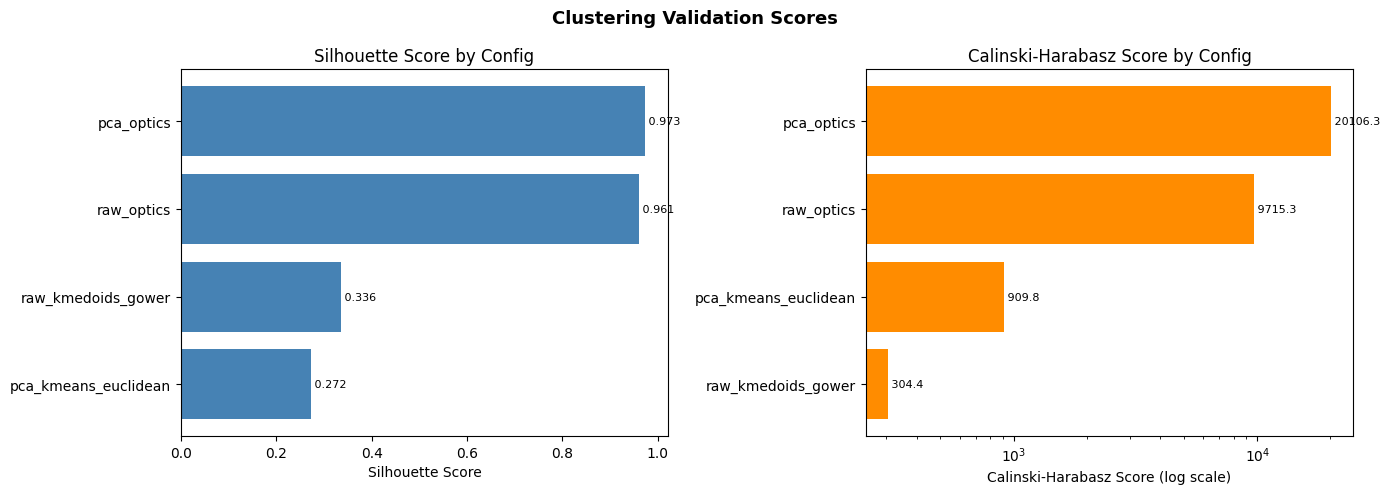

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Silhouette (sort descending) ---
sil_sorted = df.sort_values("silhouette", ascending=False)
axes[0].barh(sil_sorted["config"], sil_sorted["silhouette"], color="steelblue")
axes[0].set_xlabel("Silhouette Score")
axes[0].set_title("Silhouette Score by Config")
axes[0].invert_yaxis()
for i, v in enumerate(sil_sorted["silhouette"]):
        axes[0].text(v, i, f" {v:.3f}", va="center", fontsize=8)

# --- Calinski-Harabasz (log scale, sort descending) ---
ch_sorted = df.sort_values("calinski_harabasz", ascending=False)
ch_vals = ch_sorted["calinski_harabasz"].values
axes[1].barh(ch_sorted["config"], ch_vals, color="darkorange")
axes[1].set_xscale("log")
axes[1].set_xlabel("Calinski-Harabasz Score (log scale)")
axes[1].set_title("Calinski-Harabasz Score by Config")
axes[1].invert_yaxis()
for i, v in enumerate(ch_vals):
    
    axes[1].text(v, i, f" {v:.1f}", va="center", fontsize=8)

plt.suptitle("Clustering Validation Scores", fontsize=13, fontweight="bold")
plt.tight_layout()

validation_plot_path = os.path.join(PLOTS_DIR, "validation_figure.png")
fig.savefig(validation_plot_path, dpi=200, bbox_inches="tight")

plt.show()